### 기본 라이브러리

In [43]:
import pandas as pd
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 데이터 조회 함수

In [13]:
# 데이터 확인 함수

def get_data_spec(df):
    null_ratio = (df.isnull().mean() * 100).round(2)
    spec = pd.DataFrame({
        '변수명': df.columns,
        '데이터 타입': df.dtypes.values,
        '결측치 개수': df.isnull().sum().values,
        '결측치 비율': [f"{val}%" for val in null_ratio.values]
    })
    return spec

In [ ]:
# 호출 예시
spec_df = get_data_spec(df)

### **train**

#### 1. 회원정보

In [11]:
# 1. 회원정보 데이터 병합

# 경로
path = glob.glob("./open/train/2.신용정보/*.parquet")

# 파일 병합
df_list = [pd.read_parquet(file) for file in path]
merged_df = pd.concat(df_list, ignore_index=True)

# csv로 저장
merged_df.to_csv("data/신용정보_train.csv", index=False)

In [9]:
# 데이터 불러오기
df = pd.read_csv("data/회원정보_train.csv")

In [5]:
# 데이터 확인 함수 호출
spec_df = get_data_spec(df)
spec_df

,변수명,데이터 타입,결측치 개수,결측치 비율
0,기준년월,int64,0,0.0%
1,ID,object,0,0.0%
2,남녀구분코드,int64,0,0.0%
3,연령,object,0,0.0%
4,Segment,object,0,0.0%
...,...,...,...,...
73,우수회원면제카드수_B0M,object,0,0.0%
74,기타면제카드수_B0M,object,0,0.0%
75,카드신청건수,int64,0,0.0%
76,Life_Stage,object,0,0.0%


In [8]:
df.shape

(2400000, 78)

In [ ]:
# 2. 신용정보 데이터 병합

# 경로
path = glob.glob("./open/train/2.신용정보/*.parquet")

# 파일 병합
df_list = [pd.read_parquet(file) for file in path]
merged_df = pd.concat(df_list, ignore_index=True)

# csv로 저장

merged_df.to_csv("data/신용정보_train.csv", index=False)

#### 7. 마케팅정보

In [ ]:
# 7. 마케팅정보 데이터 병합

# 경로
path = glob.glob("./open/train/8.성과정보/*.parquet")

# 파일 병합
df_list = [pd.read_parquet(file) for file in path]
merged_df = pd.concat(df_list, ignore_index=True)

# csv로 저장
merged_df.to_csv("data/성과정보_train.csv", index=False)

In [ ]:
merged_df.info()

#### 8. 성과정보

In [ ]:
# 8. 성과정보 데이터 병합

# 경로
path = glob.glob("./open/train/8.성과정보/*.parquet")

# 파일 병합
df_list = [pd.read_parquet(file) for file in path]
merged_df = pd.concat(df_list, ignore_index=True)

# csv로 저장
merged_df.to_csv("data/성과정보_train.csv", index=False)


In [16]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Data columns (total 49 columns):
 #   Column              Dtype  
---  ------              -----  
 0   기준년월                int64  
 1   ID                  object 
 2   증감율_이용건수_신용_전월      float64
 3   증감율_이용건수_신판_전월      float64
 4   증감율_이용건수_일시불_전월     float64
 5   증감율_이용건수_할부_전월      float64
 6   증감율_이용건수_CA_전월      float64
 7   증감율_이용건수_체크_전월      float64
 8   증감율_이용건수_카드론_전월     float64
 9   증감율_이용금액_신용_전월      float64
 10  증감율_이용금액_신판_전월      float64
 11  증감율_이용금액_일시불_전월     float64
 12  증감율_이용금액_할부_전월      float64
 13  증감율_이용금액_CA_전월      float64
 14  증감율_이용금액_체크_전월      float64
 15  증감율_이용금액_카드론_전월     float64
 16  증감율_이용건수_신용_분기      float64
 17  증감율_이용건수_신판_분기      float64
 18  증감율_이용건수_일시불_분기     float64
 19  증감율_이용건수_할부_분기      float64
 20  증감율_이용건수_CA_분기      float64
 21  증감율_이용건수_체크_분기      float64
 22  증감율_이용건수_카드론_분기     float64
 23  증감율_이용금액_신용_분기      float64
 24  증감율_이용금액_신판_분기      floa

In [ ]:
# 데이터 병합

file_paths = glob.glob("./open/train/7.마케팅정보/*.parquet")
df_list = [pd.read_parquet(fp) for fp in file_paths]
merged_df = pd.concat(df_list, ignore_index=True)


In [ ]:
merged_df.to_parquet("data/성과정보_train.parquet")

In [17]:
os.listdir(r'C:\Users\katch\workspace\11_파이널프로젝트관련\data')

['마케팅정보_train.csv',
 '성과정보_train.csv',
 '승인매출정보_train.csv',
 '신용정보_train.csv',
 '잔액정보_train.csv',
 '채널정보_train.csv',
 '청구입금정보_train.csv',
 '회원정보_train.csv']

In [15]:
info_list=[]
for x in os.listdir('data'):
    path=os.path.join('data',x)
    df=pd.read_csv(path)
    info_list.append(get_data_spec(df))
    df.to_csv(path, index=False,encoding='utf-8-sig')
    gc.collect()
    print(x)
info=pd.concat(info_list,ignore_index=True)


마케팅정보_test.csv
마케팅정보_train.csv
성과정보_test.csv
성과정보_train.csv


C:\Users\katch\AppData\Local\Temp\ipykernel_18420\3525840027.py:4: DtypeWarning: Columns (183) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path)


승인매출정보_test.csv


C:\Users\katch\AppData\Local\Temp\ipykernel_18420\3525840027.py:4: DtypeWarning: Columns (183) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path)


승인매출정보_train.csv
신용정보_test.csv
신용정보_train.csv
잔액정보_test.csv
잔액정보_train.csv
채널정보_test.csv
채널정보_train.csv
청구입금정보_test.csv
청구입금정보_train.csv
회원정보_test.csv
회원정보_train.csv


In [27]:
info.head()

,변수명,데이터 타입,결측치 개수,결측치 비율
0,기준년월,int64,0,0.0%
1,ID,object,0,0.0%
2,컨택건수_카드론_TM_B0M,int64,0,0.0%
3,컨택건수_리볼빙_TM_B0M,int64,0,0.0%
4,컨택건수_CA_TM_B0M,int64,0,0.0%


<BarContainer object of 1743 artists>

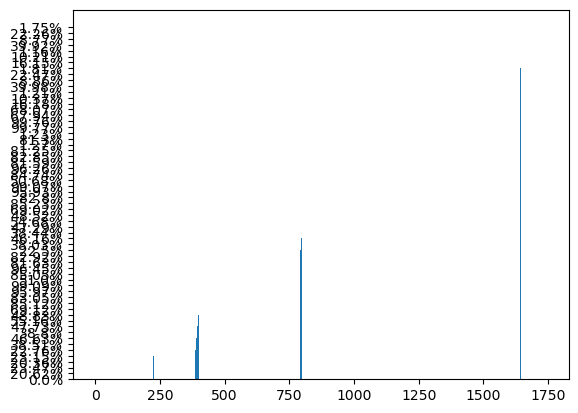

In [49]:
plt.bar(range(len(info)),info['결측치 비율'])

In [127]:
info.sort_values('결측치 비율')[-62:-56]

,변수명,데이터 타입,결측치 개수,결측치 비율
1715,_1순위신용체크구분,object,27950,1.16%
1637,_1순위신용체크구분,object,7231,1.21%
1107,RV전환가능여부,object,29473,1.23%
1065,RV전환가능여부,object,7634,1.27%
1721,최종카드발급일자,float64,41965,1.75%
1643,최종카드발급일자,float64,10854,1.81%


In [135]:
del_col=list(info.sort_values('결측치 비율').tail(62)['변수명'].unique())

In [137]:
train_path='open/train'
columns_dic={}
for x in os.listdir(train_path):
    nxt_path=os.path.join(train_path,x)
    for y in os.listdir(nxt_path):
        file_path=os.path.join(nxt_path,y)
        df=pd.read_parquet(file_path)
        columns_dic[x]=list(df.columns)
        del df
        gc.collect()
        break
        

In [171]:


# 데이터를 담을 빈 리스트를 만듭니다.
data_rows = []

for x in del_col:
    for y in columns_dic.keys():
        if x in columns_dic[y]:
            missing_rate = info[info['변수명'] == x]['결측치 비율'].iloc[0]
            
            # 각 행의 데이터를 튜플 또는 리스트 형태로 리스트에 추가합니다.
            data_rows.append((y, x, missing_rate))

# 모든 데이터가 준비되면 한 번에 DataFrame을 생성합니다.
del_col2 = pd.DataFrame(data_rows, columns=['파일', '칼럼', '결측치 비율'])
del_col2=del_col2.sort_values("파일")

print(del_col2)
del_col2.to_csv("결측치.csv",encoding='utf-8-sig',index= False)

          파일              칼럼  결측치 비율
0     1.회원정보      _1순위신용체크구분   1.21%
2     1.회원정보        최종카드발급일자   1.81%
3     1.회원정보           직장시도명  10.37%
4     1.회원정보        가입통신회사코드  16.18%
6     1.회원정보    최종유효년월_신용_이용  22.47%
19    1.회원정보  최종유효년월_신용_이용가능   8.86%
11    1.회원정보      _2순위신용체크구분  39.98%
1     2.신용정보        RV전환가능여부   1.27%
20    2.신용정보          RV신청일자  81.25%
21  3.승인매출정보  최종카드론_금융상환방식코드  81.63%
22  3.승인매출정보    최종카드론_신청경로코드  81.63%
23  3.승인매출정보        _1순위여유업종  83.05%
26  3.승인매출정보        _3순위교통업종  85.12%
25  3.승인매출정보        _2순위납부업종  85.05%
27  3.승인매출정보        _2순위여유업종  95.97%
28  3.승인매출정보        _3순위납부업종  96.45%
24  3.승인매출정보      최종카드론_대출일자  82.92%
18  3.승인매출정보        _2순위교통업종  69.12%
15  3.승인매출정보        _1순위납부업종   51.0%
16  3.승인매출정보        _3순위쇼핑업종  55.16%
29  3.승인매출정보        _3순위여유업종  99.09%
14  3.승인매출정보        _1순위교통업종  48.83%
13  3.승인매출정보        _2순위쇼핑업종  47.73%
12  3.승인매출정보          _3순위업종  46.63%
10  3.승인매출정보        _1순위쇼핑업종   38.8%
9   3.승인매출정보          _2순위업종  38.51%
7

In [141]:
del_col2=sorted(del_col2)

In [143]:
#결측치 10프로 이상인 칼럼. 이 외에는 1.9퍼센트 이하
del_col2

[('1.회원정보', '_1순위신용체크구분'),
 ('1.회원정보', '_2순위신용체크구분'),
 ('1.회원정보', '가입통신회사코드'),
 ('1.회원정보', '직장시도명'),
 ('1.회원정보', '최종유효년월_신용_이용'),
 ('1.회원정보', '최종유효년월_신용_이용가능'),
 ('1.회원정보', '최종카드발급일자'),
 ('2.신용정보', 'RV신청일자'),
 ('2.신용정보', 'RV전환가능여부'),
 ('3.승인매출정보', '_1순위교통업종'),
 ('3.승인매출정보', '_1순위납부업종'),
 ('3.승인매출정보', '_1순위쇼핑업종'),
 ('3.승인매출정보', '_1순위업종'),
 ('3.승인매출정보', '_1순위여유업종'),
 ('3.승인매출정보', '_2순위교통업종'),
 ('3.승인매출정보', '_2순위납부업종'),
 ('3.승인매출정보', '_2순위쇼핑업종'),
 ('3.승인매출정보', '_2순위업종'),
 ('3.승인매출정보', '_2순위여유업종'),
 ('3.승인매출정보', '_3순위교통업종'),
 ('3.승인매출정보', '_3순위납부업종'),
 ('3.승인매출정보', '_3순위쇼핑업종'),
 ('3.승인매출정보', '_3순위업종'),
 ('3.승인매출정보', '_3순위여유업종'),
 ('3.승인매출정보', '최종카드론_금융상환방식코드'),
 ('3.승인매출정보', '최종카드론_대출일자'),
 ('3.승인매출정보', '최종카드론_신청경로코드'),
 ('5.잔액정보', '연체일자_B0M'),
 ('6.채널정보', 'OS구분코드'),
 ('8.성과정보', '혜택수혜율_B0M'),
 ('8.성과정보', '혜택수혜율_R3M')]

In [97]:
info.sort_values('결측치 비율').tail(57)['결측치 비율']

1643     1.81%
1691    10.21%
1613    10.37%
1685    16.15%
1607    16.18%
224     20.36%
175     20.62%
1720    22.26%
1642    22.47%
793      22.5%
387     22.76%
225     23.15%
176     23.47%
795     38.03%
799     38.44%
389     38.51%
393      38.8%
1718    39.92%
1640    39.98%
797     46.16%
391     46.63%
801     47.29%
395     47.73%
805     48.52%
399     48.83%
817     50.68%
411      51.0%
803     54.68%
397     55.16%
1386    67.94%
1491    68.07%
807     69.02%
401     69.12%
1719     8.77%
1641     8.86%
1049    81.25%
1091     81.3%
899     81.59%
900     81.59%
494     81.63%
493     81.63%
811      82.8%
902     82.85%
496     82.92%
405     83.05%
819     84.74%
413     85.05%
403     85.12%
809     85.23%
813     95.93%
407     95.97%
821     96.26%
415     96.45%
815     99.07%
409     99.09%
1216    99.76%
1134    99.77%
Name: 결측치 비율, dtype: object

In [167]:
info.head()

,변수명,데이터 타입,결측치 개수,결측치 비율
0,기준년월,int64,0,0.0%
1,ID,object,0,0.0%
2,컨택건수_카드론_TM_B0M,int64,0,0.0%
3,컨택건수_리볼빙_TM_B0M,int64,0,0.0%
4,컨택건수_CA_TM_B0M,int64,0,0.0%


In [ ]:
-- 데이터 EDA 와 함께, 캐글/데이콘의 유사한 대회에서 토크, 코드 체크(특히 코드는 AI에게 학습시킬 수 있게 텍스트, PDF 로 따두고 미리 학습시키거나 핵심만 추출)

-- EDA할때 마인드 맵을 만들어서(gitmind) 각 컬럼의 연결성을 의미적으로 재구성하고 주석을 남겨서 공유 권장.

-- Data pipline(데이터의 추출, 변환 및 로드(ETL)를 자동화하는 시스템)은 어떻게 할지 등등 미리 결정하고, 용량 부족하면 google AI Pro 업그레이드 하면 한달간 2.5TB 스토리지 사용가능

-- 코드 공유, 스코어와 각 방법론의 파이프라인 관리, 협업은 어떻게 할지 정해둘것. 개인적으론 MLflow, Airflow 같은 패키지도 고려 중이나 gitmind 같은 프로그램으로 flowchart 만들면서 git을 병행하는 것도 좋음. 이 부분은 학습력에 달린 문제이므로 조에서 토의를 통해 결정.
--- 환경 관리: Conda 또는 Poetry 등을 사용하여 팀원 간 동일한 개발 환경 유지. requirements.txt 관리.
--- 코드 재사용성 반드시 고려해서 코딩. e.g. 전처리로 특정 컬럼 제거한 버전과 그렇지 않은 버전의 데이터가 분기된다고 가정해도 이후 동일하게 scalar 처리할 수도 있기 때문(특히 행렬 수가 달라질 수 있으니 유연성에 주의). 극단적으로 쪼갠 예시지만, 각자가 각자의 방법으로 만든 모델에서 동일한 코드를 쓰는 것은 비효율이 될 수 있음.
--- Jupyter Notebook을 사용할 경우 .ipynb 파일 자체를 버전 관리하기보다는 핵심 로직은 .py 파일로 분리하고, 노트북은 실험 및 시각화 용도로 활용하는 것이 효율적.

-- 오래 걸리는 작업은 어떻게 처리할지 컴퓨팅 자원 고려(로컬, kaggle, colab). 추천하는 패턴은 우선 작은 것부터 시작해 인사이트를 얻고 크고 무거운 모델에 적용. 낮 시간동안은 colab에서 돌리고, 로컬에선 작업에 방해가 안 되도록 리서치, 테스트 코드만 작성. kaggle은 colab 돌아가는 동안 2안으로(GPU 지원됨). 24시간 컴퓨터를 켤수 있는 팀원이라면 해당 팀원에게 양해를 구하는 것도 고려(다만 3주면 넉넉하니 큰 문제는 없을것).

놓칠 수도 있는 자잘한 포인트
-- Reproducibility (재현성): 실험 결과의 재현성 확보를 위해 random_state 고정, 데이터 로딩/전처리/모델링 코드의 명확성 유지.

-- 파생변수 만드는 것을 고려하되 컬럼 자체가 많으니 주성분 분석 처럼 압축하는 방법론도 고려.

-- label encoder 같은 코드는 수업에 있는거 바로 그대로 쓰지 말고 범주형이라 판단되면 onehot으로 해야할지 고민하고 사용.

-- CV는 Stratified K-Fold 쓰고 세그먼트의 클래스 불균형에 신경쓸 것. F1 Score를 따지는게 원래 공모전의 의의였던 만큼(다만 실제로는 강사님 사용한 예측모델이 뭔지 맞춰야 점수가 높을것. 그러나 중요한 것은 빠르게 논리적, 체계적 EDA와 분석에 따른 피처 엔지니어링으로 성능을 높혔고 이 과정에서 뭘 배우고 어떤 성과를 낼 수 있을지)

-- 이 프로젝트는 점수가 문제가 아니므로 모델 및 앙상블 조합, 전처리 선택의 논리적 근거를 EDA를 통해 내는 것에 중점
프로젝트 배경 및 목표 설정(생략 가능)
데이터 이해 및 탐색 (EDA - Exploratory Data Analysis)
데이터 전처리 (Data Preprocessing) 및 특성 공학 (Feature Engineering)
모델링 (Modeling)
성능 평가 및 결과 분석

2, 3~5를 텀을 정해두고 사이클을 돌며 반복.